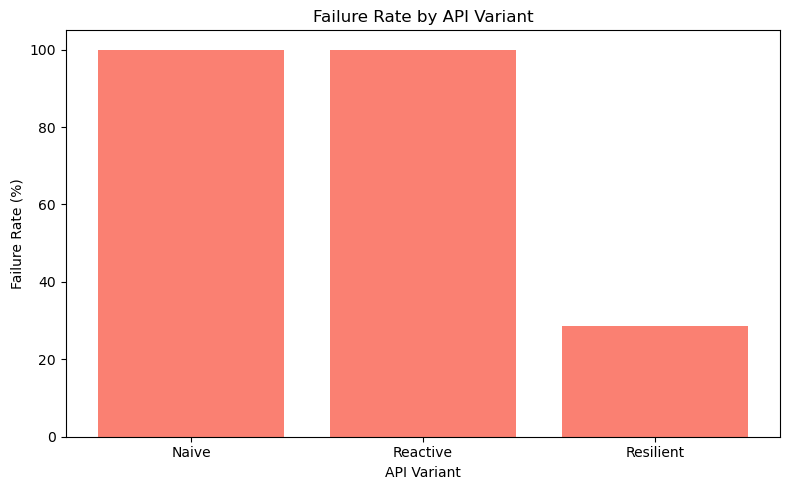

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame manually
data = {
    'API Variant': ['Naive', 'Reactive', 'Resilient'],
    'Avg Response Time (ms)': [10.23, 4.39, 4136.52],
    'Failure Rate (%)': [100.0, 100.0, 28.6]
}
df = pd.DataFrame(data)


# Bar chart for failure rate
plt.figure(figsize=(8, 5))
plt.bar(df['API Variant'], df['Failure Rate (%)'], color='salmon')
plt.title('Failure Rate by API Variant')
plt.ylabel('Failure Rate (%)')
plt.xlabel('API Variant')
plt.tight_layout()
plt.show()


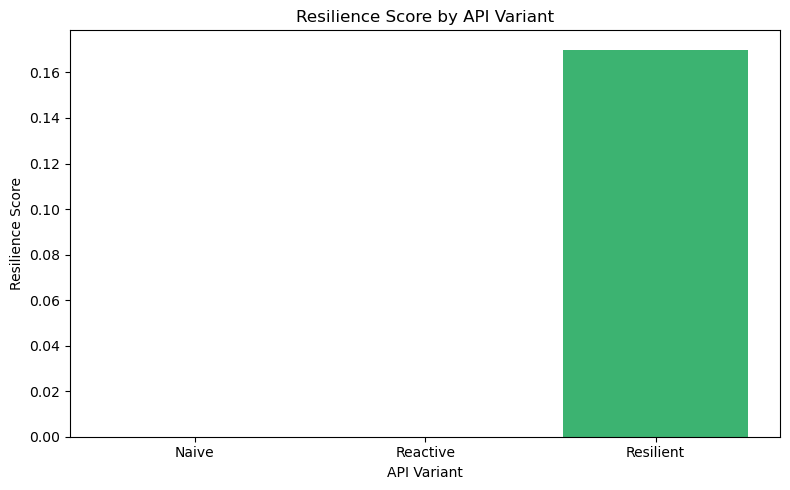

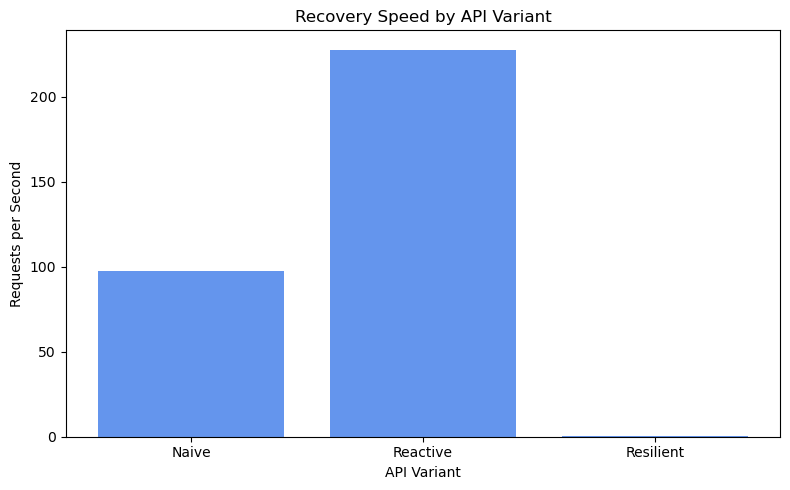

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Define resilience metrics
data = {
    'API Variant': ['Naive', 'Reactive', 'Resilient'],
    'Avg Response Time (s)': [0.01023, 0.00439, 4.13652],
    'Fallback Rate (%)': [100.0, 100.0, 28.6],
    'Recovery Speed': [1/0.01023, 1/0.00439, 1/4.13652],
    'Resilience Score': [0.0, 0.0, 0.17]
}

df = pd.DataFrame(data)

# Bar chart for Resilience Score
plt.figure(figsize=(8, 5))
plt.bar(df['API Variant'], df['Resilience Score'], color='mediumseagreen')
plt.title('Resilience Score by API Variant')
plt.ylabel('Resilience Score')
plt.xlabel('API Variant')
plt.tight_layout()
plt.show()

# Optional: Bar chart for Recovery Speed
plt.figure(figsize=(8, 5))
plt.bar(df['API Variant'], df['Recovery Speed'], color='cornflowerblue')
plt.title('Recovery Speed by API Variant')
plt.ylabel('Requests per Second')
plt.xlabel('API Variant')
plt.tight_layout()
plt.show()


[PLOT] Saved confusion matrix
[PLOT] Saved ROC curve


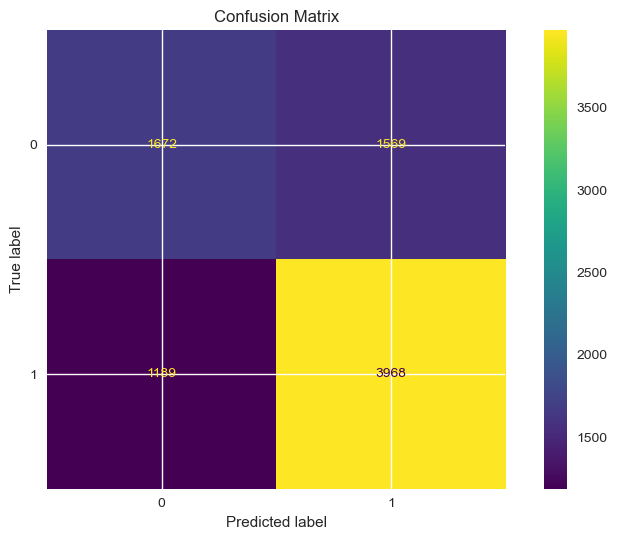

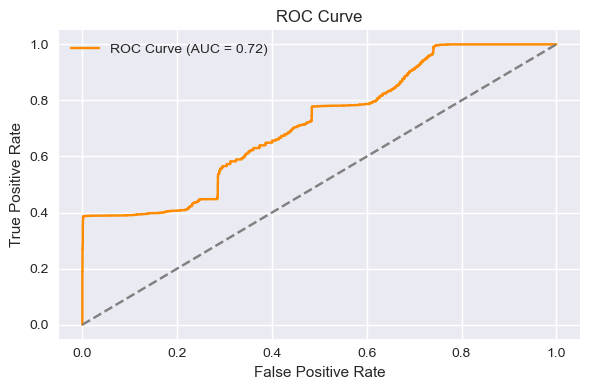

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

# Load and preprocess data
df = pd.read_csv("chaos_events1.csv")
STRESSOR_MAP = {
    "timeout": 0,
    "latency": 1,
    "failure": 2,
    "none": 3
}

df["stressor_type"] = df["stressor"].map(STRESSOR_MAP)
df["success"] = df["success"].astype(int)

feature_cols = ["stressor_type", "value", "cpu", "mem", "confidence"]
X = df[feature_cols]
y = df["fallback_used"].astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_display = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
print("[PLOT] Saved confusion matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png")
print("[PLOT] Saved ROC curve")


Accuracy     : 0.6716
Precision    : 0.7166
Recall       : 0.7694
F1-Score     : 0.7421
ROC-AUC      : 0.7152
[PLOT] Saved confusion matrix
[PLOT] Saved ROC curve


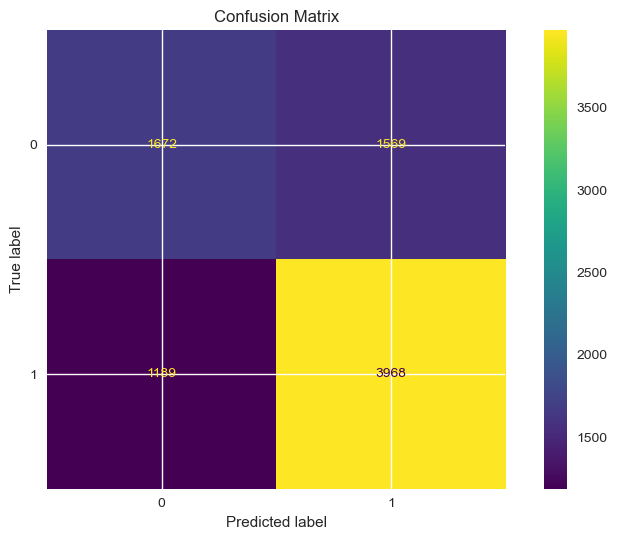

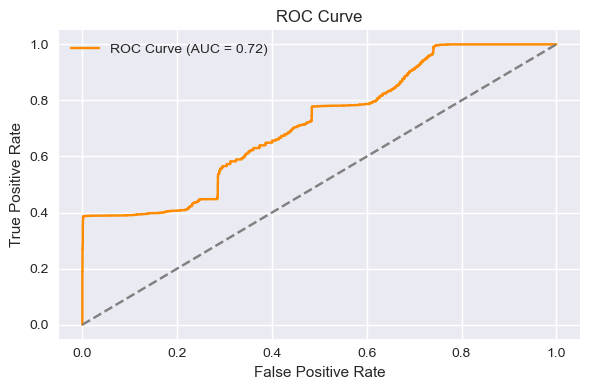

In [22]:
#Logistic regression model

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
import matplotlib.pyplot as plt

# Define stressor encoding
STRESSOR_MAP = {
    "timeout": 0,
    "latency": 1,
    "failure": 2,
    "none": 3
}

# Load dataset
df = pd.read_csv("chaos_events1.csv")

# Preprocess
df["stressor_type"] = df["stressor"].map(STRESSOR_MAP)
df["fallback_used"] = df["fallback_used"].astype(int)

# Select features and target
feature_cols = ["stressor_type", "value", "cpu", "mem", "confidence"]
X = df[feature_cols]
y = df["fallback_used"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)

# Print results
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1-Score     : {f1:.4f}")
print(f"ROC-AUC      : {roc_auc:.4f}")

# Optional: Plot confusion matrix
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
print("[PLOT] Saved confusion matrix")

# Optional: Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png")
print("[PLOT] Saved ROC curve")
